<a href="https://www.kaggle.com/code/lalit7881/ev-charging-optimization?scriptVersionId=305735601" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mjawad17/ev-charging-and-grid-optimization-data/charging_ev_and_grid_optimization_dataset.csv


## Loading dataset

In [2]:
df= pd.read_csv("/kaggle/input/datasets/mjawad17/ev-charging-and-grid-optimization-data/charging_ev_and_grid_optimization_dataset.csv")

In [3]:
df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [4]:
df.tail()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
8349,3/28/2025 23:15,ST011,Urban,EV18349,Bus,3/28/2025 23:15,3/28/2025 23:28,3/28/2025 23:52,13,30,...,14.67,0.131198,Low,Clear,Friday,Off-Peak,24.557664,CH6,Low,-15.495699
8350,3/28/2025 23:30,ST019,Urban,EV18350,Two-Wheeler,3/28/2025 23:30,3/28/2025 23:42,3/29/2025 0:50,12,30,...,8.24,0.126224,Low,Cloudy,Friday,Off-Peak,33.027807,CH2,Medium,-14.885047
8351,3/28/2025 23:45,ST005,Highway,EV18351,Bus,3/28/2025 23:45,3/28/2025 23:55,3/29/2025 7:00,10,75,...,9.90,0.370010,Low,Cloudy,Friday,Off-Peak,27.381072,CH7,Medium,-5.713488
8352,3/29/2025 0:00,ST014,Highway,EV18352,Two-Wheeler,3/29/2025 0:00,3/29/2025 0:22,3/29/2025 1:45,22,40,...,14.85,0.105252,Low,Cloudy,Saturday,Off-Peak,25.138820,CH1,High,-27.040944
8353,3/29/2025 0:15,ST020,Urban,EV18353,Two-Wheeler,3/29/2025 0:15,3/29/2025 0:34,3/29/2025 1:26,19,60,...,7.53,0.246519,Low,Clear,Saturday,Off-Peak,33.177527,CH10,Low,-22.667824


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [6]:
df.describe

<bound method NDFrame.describe of             timestamp station_id location_type vehicle_id vehicle_type  \
0       1/1/2025 0:00      ST004         Urban    EV10000  Two-Wheeler   
1       1/1/2025 0:15      ST005         Urban    EV10001  Two-Wheeler   
2       1/1/2025 0:30      ST019       Highway    EV10002          Car   
3       1/1/2025 0:45      ST008         Urban    EV10003  Two-Wheeler   
4       1/1/2025 1:00      ST008       Highway    EV10004  Two-Wheeler   
...               ...        ...           ...        ...          ...   
8349  3/28/2025 23:15      ST011         Urban    EV18349          Bus   
8350  3/28/2025 23:30      ST019         Urban    EV18350  Two-Wheeler   
8351  3/28/2025 23:45      ST005       Highway    EV18351          Bus   
8352   3/29/2025 0:00      ST014       Highway    EV18352  Two-Wheeler   
8353   3/29/2025 0:15      ST020         Urban    EV18353  Two-Wheeler   

         arrival_time charging_start_time charging_end_time  waiting_time  \


In [7]:
df.isnull().sum()

timestamp                 0
station_id                0
location_type             0
vehicle_id                0
vehicle_type              0
arrival_time              0
charging_start_time       0
charging_end_time         0
waiting_time              0
battery_capacity_kWh      0
initial_soc               0
final_soc                 0
energy_consumed_kWh       0
charging_power_kW         0
charging_duration         0
queue_length              0
station_load              0
electricity_price         0
renewable_energy_ratio    0
traffic_density           0
weather_condition         0
day_of_week               0
time_slot                 0
charging_demand           0
assigned_charger_id       0
charging_priority         0
optimization_reward       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

timestamp                  object
station_id                 object
location_type              object
vehicle_id                 object
vehicle_type               object
arrival_time               object
charging_start_time        object
charging_end_time          object
waiting_time                int64
battery_capacity_kWh        int64
initial_soc               float64
final_soc                 float64
energy_consumed_kWh       float64
charging_power_kW           int64
charging_duration         float64
queue_length                int64
station_load              float64
electricity_price         float64
renewable_energy_ratio    float64
traffic_density            object
weather_condition          object
day_of_week                object
time_slot                  object
charging_demand           float64
assigned_charger_id        object
charging_priority          object
optimization_reward       float64
dtype: object

In [10]:
df.shape

(8354, 27)

In [11]:
df.columns

Index(['timestamp', 'station_id', 'location_type', 'vehicle_id',
       'vehicle_type', 'arrival_time', 'charging_start_time',
       'charging_end_time', 'waiting_time', 'battery_capacity_kWh',
       'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW',
       'charging_duration', 'queue_length', 'station_load',
       'electricity_price', 'renewable_energy_ratio', 'traffic_density',
       'weather_condition', 'day_of_week', 'time_slot', 'charging_demand',
       'assigned_charger_id', 'charging_priority', 'optimization_reward'],
      dtype='object')

In [12]:
df.nunique()

timestamp                 8354
station_id                  20
location_type                2
vehicle_id                8354
vehicle_type                 3
arrival_time              8354
charging_start_time       8304
charging_end_time         8109
waiting_time                29
battery_capacity_kWh         5
initial_soc               8354
final_soc                 4181
energy_consumed_kWh       8337
charging_power_kW            4
charging_duration         8337
queue_length                16
station_load              7996
electricity_price         1000
renewable_energy_ratio    8354
traffic_density              3
weather_condition            3
day_of_week                  7
time_slot                    2
charging_demand           8354
assigned_charger_id         10
charging_priority            3
optimization_reward       8354
dtype: int64

## EDA

In [13]:
# Convert time columns
time_cols = ['timestamp', 'arrival_time', 'charging_start_time', 'charging_end_time']
for col in time_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Check data
print(df.head())

            timestamp station_id location_type vehicle_id vehicle_type  \
0 2025-01-01 00:00:00      ST004         Urban    EV10000  Two-Wheeler   
1 2025-01-01 00:15:00      ST005         Urban    EV10001  Two-Wheeler   
2 2025-01-01 00:30:00      ST019       Highway    EV10002          Car   
3 2025-01-01 00:45:00      ST008         Urban    EV10003  Two-Wheeler   
4 2025-01-01 01:00:00      ST008       Highway    EV10004  Two-Wheeler   

         arrival_time charging_start_time   charging_end_time  waiting_time  \
0 2025-01-01 00:00:00 2025-01-01 00:12:00 2025-01-01 04:33:00            12   
1 2025-01-01 00:15:00 2025-01-01 00:23:00 2025-01-01 01:12:00             8   
2 2025-01-01 00:30:00 2025-01-01 00:41:00 2025-01-01 01:35:00            11   
3 2025-01-01 00:45:00 2025-01-01 00:54:00 2025-01-01 03:29:00             9   
4 2025-01-01 01:00:00 2025-01-01 01:08:00 2025-01-01 06:14:00             8   

   battery_capacity_kWh  ...  electricity_price  renewable_energy_ratio  \
0    

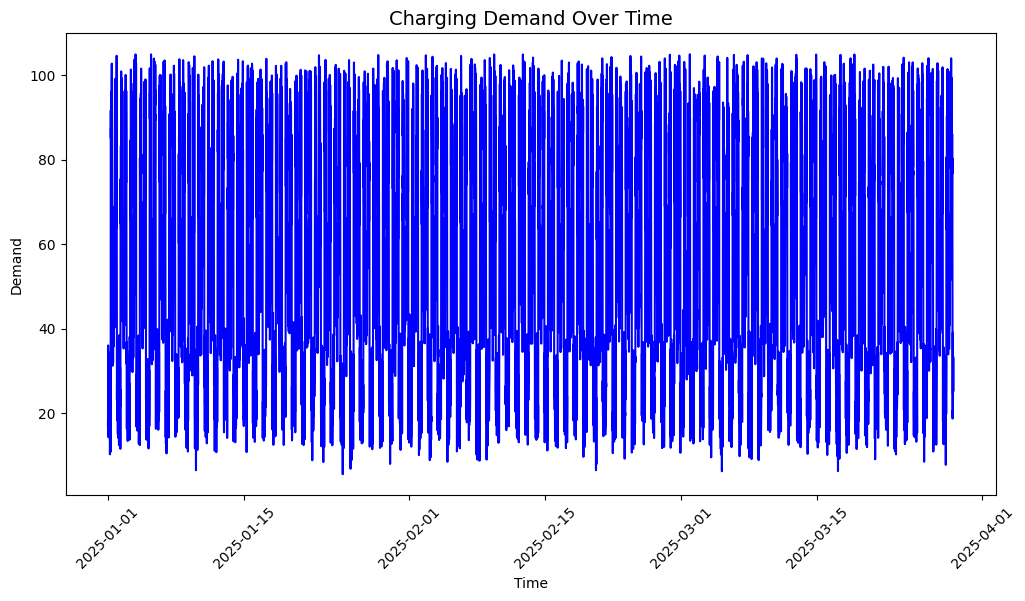

In [14]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="charging_demand",
    color="blue"
)

plt.title("Charging Demand Over Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.show()

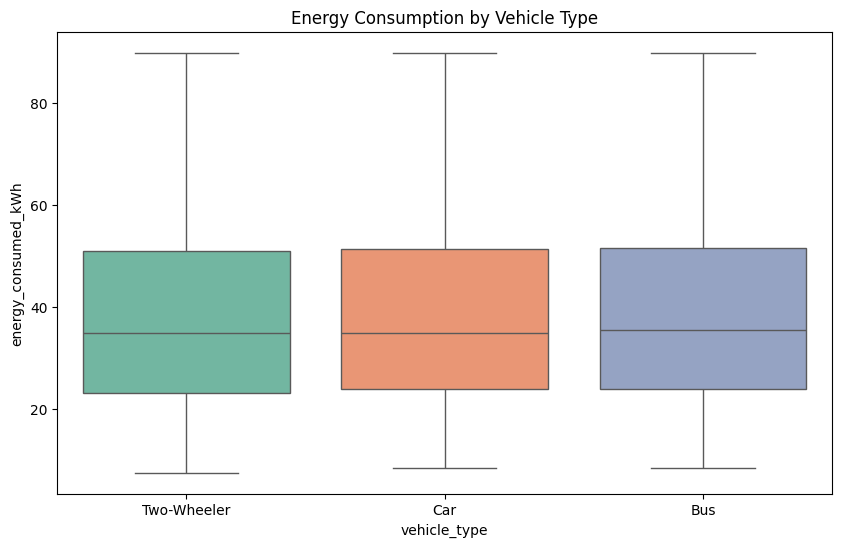

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="vehicle_type",
    y="energy_consumed_kWh",
    palette="Set2"
)

plt.title("Energy Consumption by Vehicle Type")
plt.show()

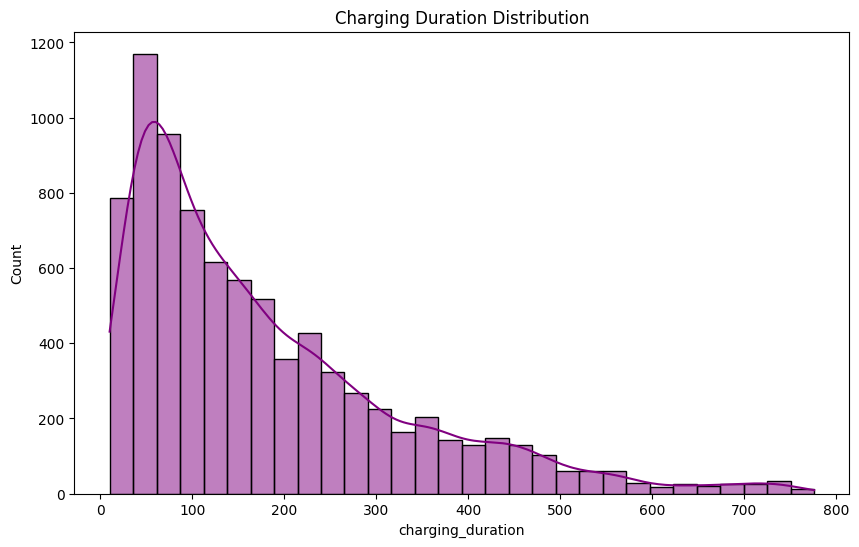

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["charging_duration"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Charging Duration Distribution")
plt.show()

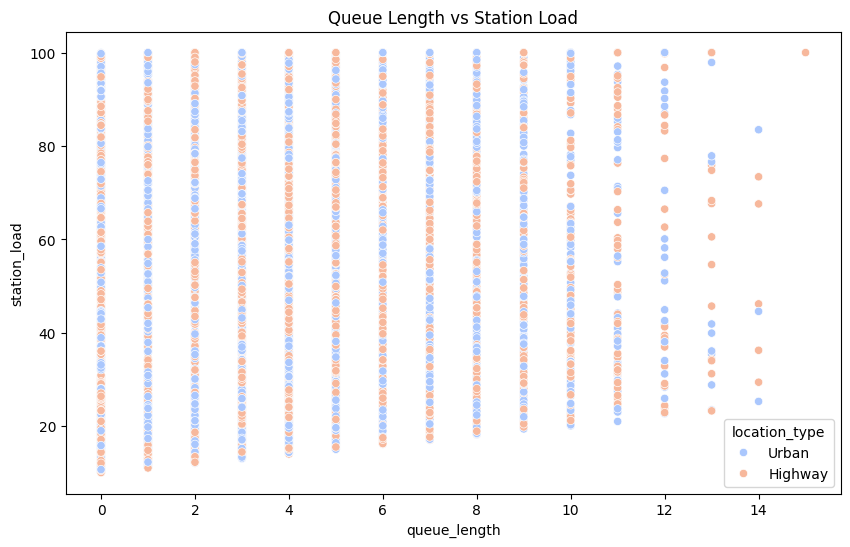

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="queue_length",
    y="station_load",
    hue="location_type",
    palette="coolwarm"
)

plt.title("Queue Length vs Station Load")
plt.show()

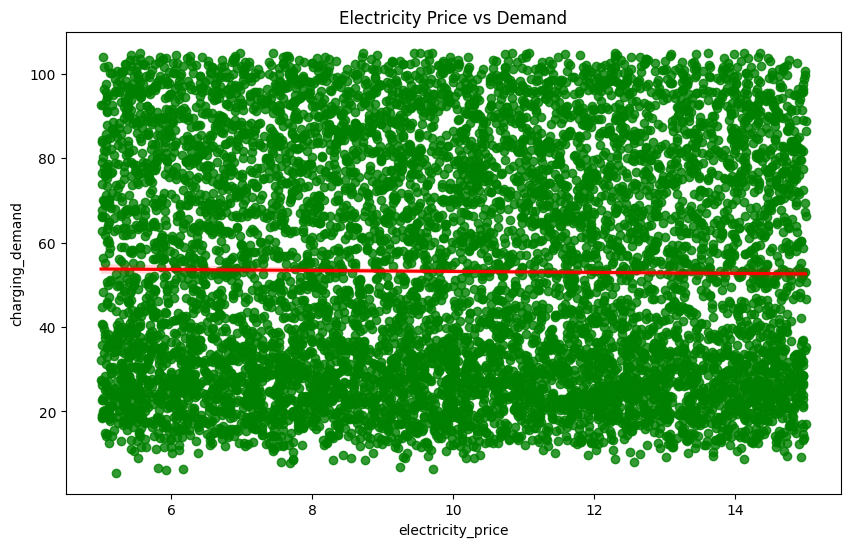

In [18]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="electricity_price",
    y="charging_demand",
    scatter_kws={"color":"green"},
    line_kws={"color":"red"}
)

plt.title("Electricity Price vs Demand")
plt.show()

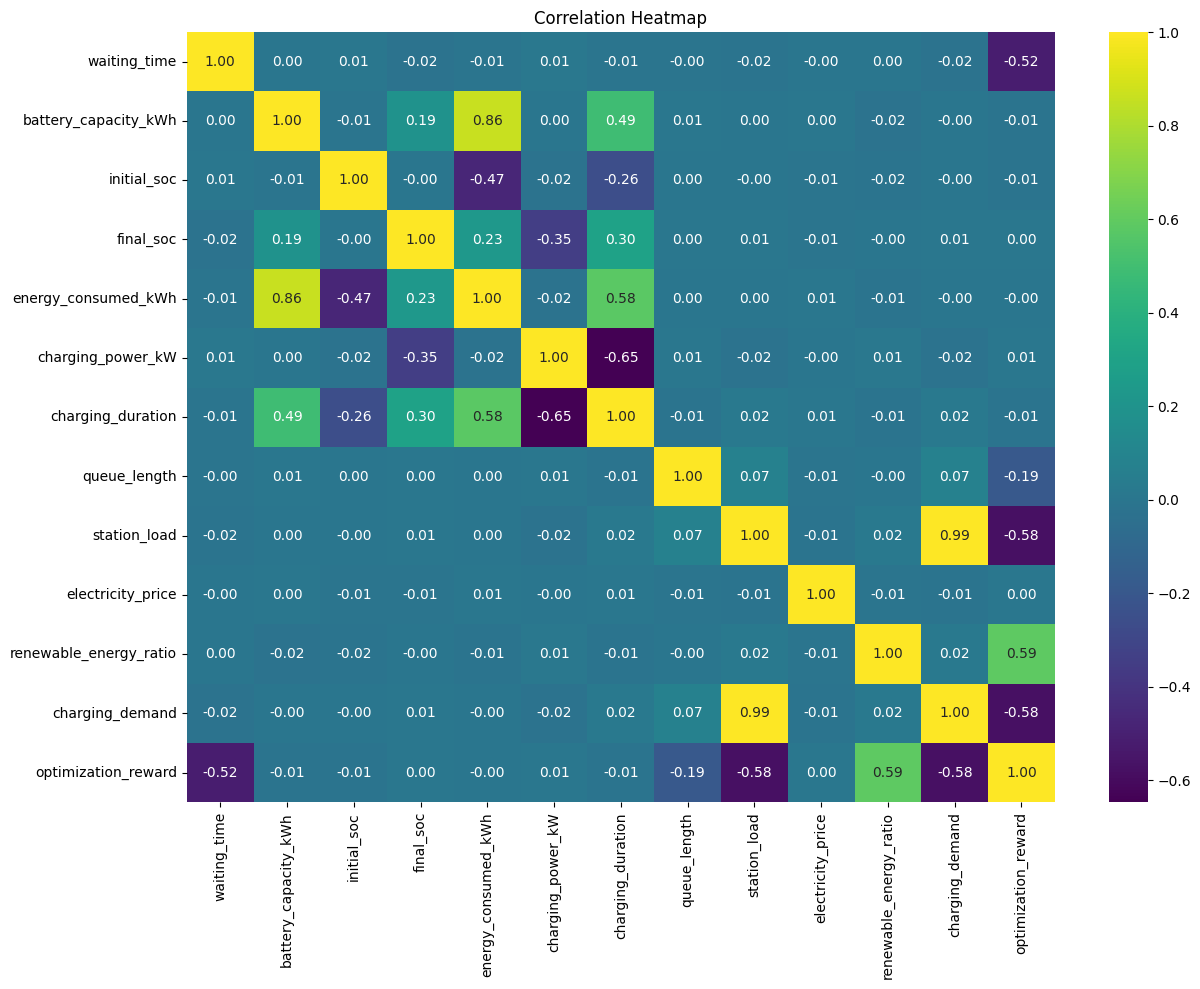

In [19]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

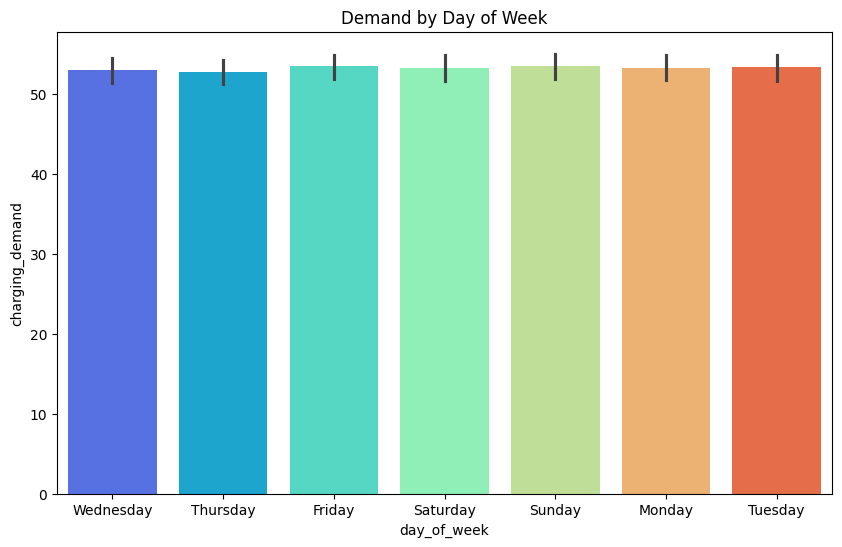

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="day_of_week",
    y="charging_demand",
    palette="rainbow"
)

plt.title("Demand by Day of Week")
plt.show()

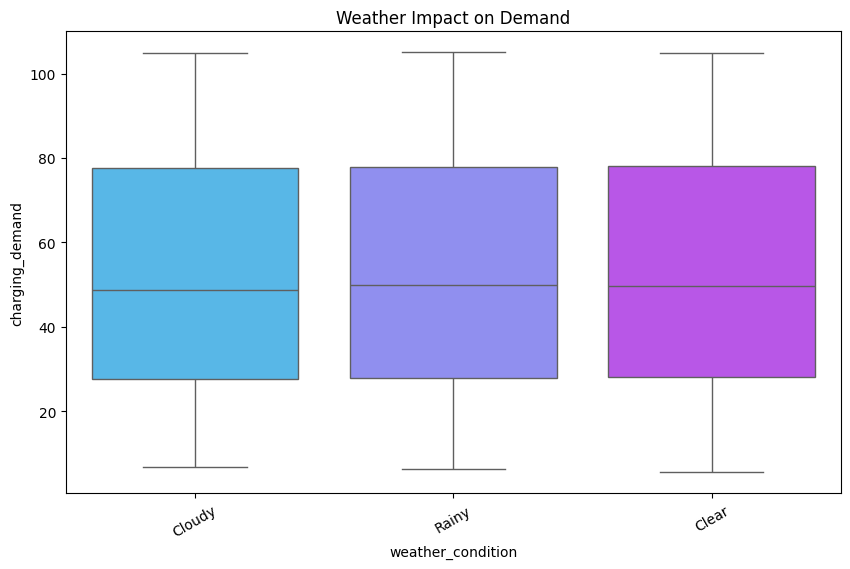

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="weather_condition",
    y="charging_demand",
    palette="cool"
)

plt.title("Weather Impact on Demand")
plt.xticks(rotation=30)
plt.show()

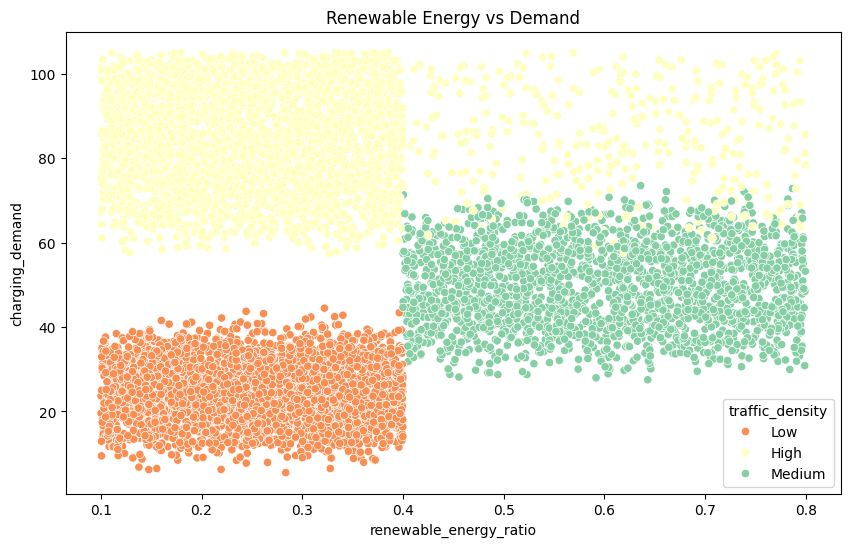

In [22]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="renewable_energy_ratio",
    y="charging_demand",
    hue="traffic_density",
    palette="Spectral"
)

plt.title("Renewable Energy vs Demand")
plt.show()

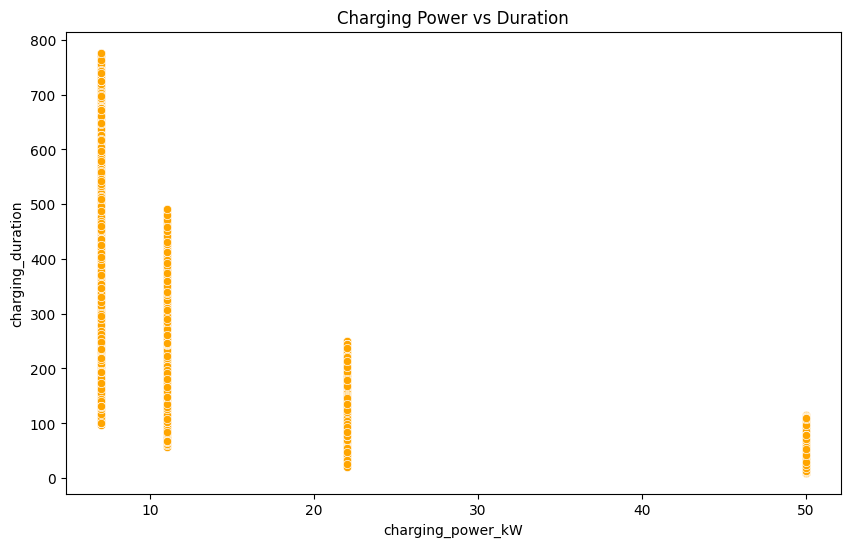

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="charging_power_kW",
    y="charging_duration",
    color="orange"
)

plt.title("Charging Power vs Duration")
plt.show()

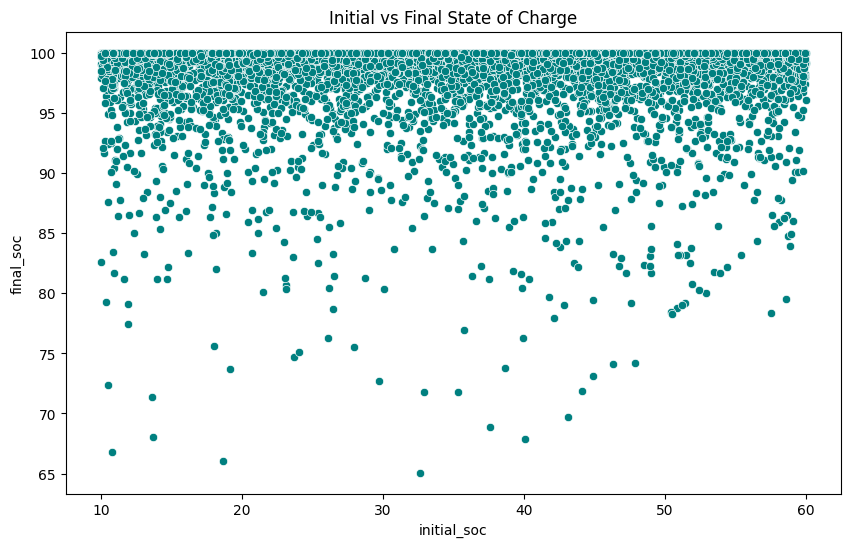

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="initial_soc",
    y="final_soc",
    color="teal"
)

plt.title("Initial vs Final State of Charge")
plt.show()

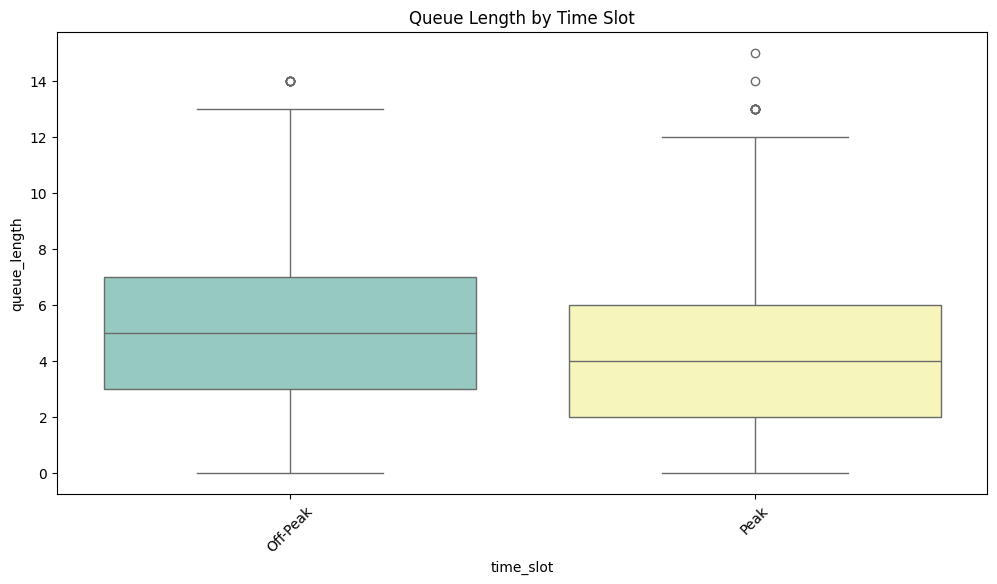

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="time_slot",
    y="queue_length",
    palette="Set3"
)

plt.title("Queue Length by Time Slot")
plt.xticks(rotation=45)
plt.show()

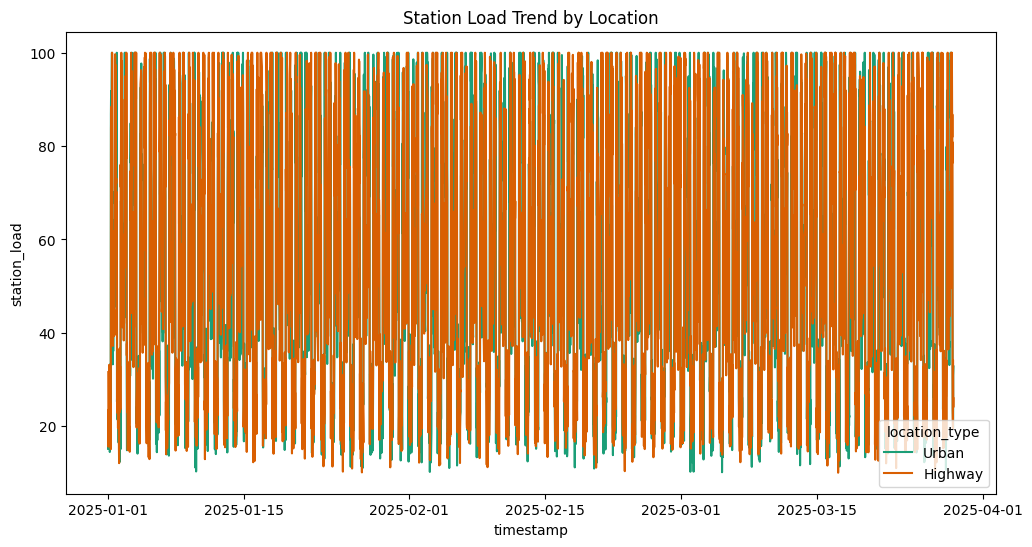

In [26]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="station_load",
    hue="location_type",
    palette="Dark2"
)

plt.title("Station Load Trend by Location")
plt.show()

## Feature engineering

In [27]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, classification_report

In [28]:
# Convert charging_demand into binary classification
df['target'] = (df['charging_demand'] > df['charging_demand'].median()).astype(int)

In [29]:
leakage_cols = [
    'charging_demand',   # original target
    'charging_end_time', # future info
    'optimization_reward'
]

df = df.drop(columns=leakage_cols)

In [30]:
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

df = df.drop(columns=['timestamp', 'arrival_time', 'charging_start_time'])

In [31]:
X = df.drop(columns=['target'])
y = df['target']

In [32]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [34]:
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}


Logistic Regression
Accuracy: 0.9790544584081389
ROC-AUC: 0.9985817838008194
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       836
           1       0.98      0.98      0.98       835

    accuracy                           0.98      1671
   macro avg       0.98      0.98      0.98      1671
weighted avg       0.98      0.98      0.98      1671


Random Forest
Accuracy: 0.9784560143626571
ROC-AUC: 0.9973920579892847
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       836
           1       0.98      0.97      0.98       835

    accuracy                           0.98      1671
   macro avg       0.98      0.98      0.98      1671
weighted avg       0.98      0.98      0.98      1671


Decision Tree
Accuracy: 0.9736684619988031
ROC-AUC: 0.9736691688393547
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       836
           1   

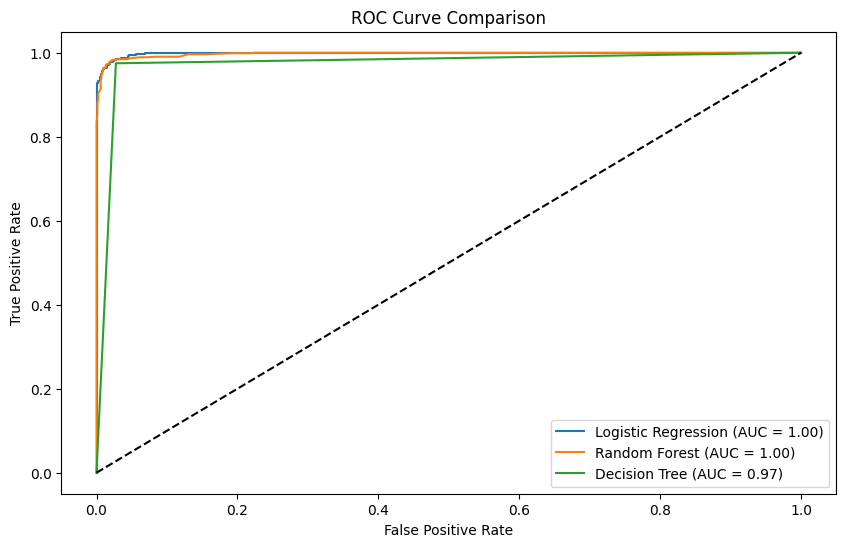

In [36]:
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = acc
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("ROC-AUC:", roc_auc)
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [37]:
print("\nModel Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Model Accuracy Comparison:
Logistic Regression: 0.9791
Random Forest: 0.9785
Decision Tree: 0.9737


## Thank you..pls upvote!!!!!!